## Save time series of FCI L1C-RRAD and L2-CLM products to netcdf format

Input: raw zip files downloaded from EUMETSAT.

Each zip file extracts to 40 body chunk .nc files + 1 trailer chunk .nc file + metadata.
Each body chunk is a portion of the full disk scan at a given timestep.
For each FD scan, this code reconstructs a region of interest (lon_min, lon_max, lat_min, lat_max) over a time span of interest (t0 -> t1). 
FD scans are separated by 10 minutes. Note: the start time in the RRAD and CLM file names differ by a few seconds.

Output: reconstructed snapshot saved as a dataset with the FCI channels as variables and x,y (lon,lat) as dimensions/coordinates.

In [ ]:
"""
MTG FCI L1C (RRAD) & L2 (CLM) processing workflow (separate .nc per product)

1. Loop through time steps
2. Unzip FCI and CLM files into temp folder
3. Load only radiance channels
4. Crop and resample
5. Save .nc
6. Empty temp folder for next file
"""

from zipfile import ZipFile
import re
import os
from glob import glob
from datetime import datetime
from satpy.scene import Scene
from satpy import find_files_and_readers
from pyresample import create_area_def
import xarray as xr
import shutil
import gc

# -----------------------------
# PARAMETERS
# -----------------------------
dirin = "/Users/luciereymondet/GitHub/GOFLOW_LR/data/raw"
dirout_unzip = "/Users/luciereymondet/GitHub/GOFLOW_LR/data/tmp"
dirout_fci = "/Users/luciereymondet/GitHub/GOFLOW_LR/data/processed/1C-RRAD_nc"
dirout_clm = "/Users/luciereymondet/GitHub/GOFLOW_LR/data/processed/2-CLM_nc"

os.makedirs(dirout_fci, exist_ok=True)
os.makedirs(dirout_clm, exist_ok=True)
os.makedirs(dirout_unzip, exist_ok=True)

t0 = datetime.strptime("20250202000000", "%Y%m%d%H%M%S")
t1 = datetime.strptime("20250203000000", "%Y%m%d%H%M%S")

# Area of interest
lon_min, lon_max = 10.0, 21.0
lat_min, lat_max = -45.0, -30.0

area_def = create_area_def(
    area_id='geo_area',
    projection={'proj': 'latlong', 'datum': 'WGS84'},
    resolution=(0.02, 0.02),
    area_extent=(lon_min, lat_min, lon_max, lat_max)
)

# -----------------------------
# UTILITY FUNCTIONS
# -----------------------------
def get_radiance_channels(all_channels):
    """Keep only radiance channels (discard metadata)."""
    return [ch for ch in all_channels if not re.search(
        r'_(earth_sun_distance|index_map|pixel_quality|platform_altitude|subsatellite_latitude|subsatellite_longitude|\
            subsolar_latitude|subsolar_longitude|sun_satellite_distance|swath_direction|swath_number|time)$',
        ch
    )]

def unzip_file(zip_path, out_dir):
    """Unzip a single zip file to out_dir."""
    os.makedirs(out_dir, exist_ok=True)
    with ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)

def get_fci_scene(data_dir, product, start_time=None, end_time=None, fmt=None):
    """Load FCI Scene using Satpy."""
    if product == "L1C":
        files = find_files_and_readers(base_dir=data_dir, reader="fci_l1c_nc")
        return Scene(filenames=files)
    else:  # L2
        reader = "fci_l2_nc" if fmt == "nc" else "fci_l2_grib"
        filenames = glob(os.path.join(data_dir, f"*{product}*"))
        return Scene(filenames=filenames, reader=reader)

# -----------------------------
# MAIN LOOP OVER TIME STEPS
# -----------------------------
files = [f for f in os.listdir(dirin) if f.endswith(".zip") and ("FCI" in f)]

for f in files:
    match = re.search(r'OPE_(\d{14})_', f)
    if not match:
        continue
    sensing_time = datetime.strptime(match.group(1), "%Y%m%d%H%M%S")
    if not (t0 <= sensing_time < t1):
        continue
    
    # Unzip
    unzip_file(os.path.join(dirin, f), dirout_unzip)

    # -----------------------------
    # LOAD, CROP, RESAMPLE
    # -----------------------------
    if "1C-RRAD" in f: 
        scn = get_fci_scene(dirout_unzip, product="L1C")
        channels = get_radiance_channels(scn.available_dataset_names())
        scn.load(channels)
        scn = scn.crop(ll_bbox=(lon_min, lat_min, lon_max, lat_max))
        scn = scn.resample(area_def)
        ds = scn.to_xarray()
        outfile = os.path.join(dirout_fci, f"{sensing_time.strftime('%Y%m%d%H%M%S')}_FCI-1C-RRAD.nc")
        ds.to_netcdf(outfile)
        print(f"Saved {outfile}")
        del scn, ds

    elif "CLM" in f: 
        scn = get_fci_scene(dirout_unzip, product="CLM", fmt="bin")
        channels = get_radiance_channels(scn.available_dataset_names())
        scn.load(channels)
        scn = scn.crop(ll_bbox=(lon_min, lat_min, lon_max, lat_max))
        scn = scn.resample(area_def)
        ds = scn.to_xarray()
        outfile = os.path.join(dirout_clm, f"{sensing_time.strftime('%Y%m%d%H%M%S')}_FCI-2-CLM.nc")
        ds.to_netcdf(outfile)
        print(f"Saved {outfile}")
        del scn, ds

    # Cleanup temporary folders
    shutil.rmtree(dirout_unzip)
    gc.collect()

PermissionError: [Errno 13] Permission denied: '/Users/luciereymondet/GitHub/GOFLOW_LR/data/processed/2-CLM_nc/20250202004000_FCI-2-CLM.nc'

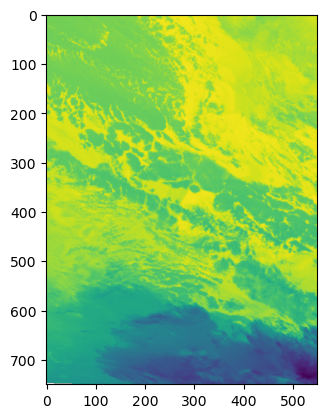

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
ds = xr.open_dataset("/Users/luciereymondet/GitHub/GOFLOW_LR/data/processed/1C-RRAD_nc/20250202000007_FCI-1C-RRAD.nc")

plt.imshow(ds["ir_87"].values)